**Contribution by WQU team member:** Avinash Sharma (avinashhbs@gmail.com)


In [1]:
import yfinance as yf

#Pick one of the funds.
#Download its data
data = yf.download("EWZ", start="2009-12-12", end="2020-01-01")

try:
    data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]
except:
    pass

# Save to CSV
data.to_csv("EWZ.csv")
print(data.head())


[*********************100%***********************]  1 of 1 completed

                Close       High        Low       Open    Volume
Date                                                            
2009-12-14  37.693214  37.823459  37.442378  37.765572  10448900
2009-12-15  37.355545  37.794509  37.263892  37.403782  12549400
2009-12-16  37.201180  37.808976  36.988931  37.553315  13657200
2009-12-17  35.479088  36.525853  35.382610  36.361841  21065300
2009-12-18  35.599670  35.874627  35.141407  35.315064  17023200


[*********************100%***********************]  1 of 1 completed

    Price           Close       High        Low       Open    Volume
    Ticker            EWZ        EWZ        EWZ        EWZ       EWZ
    Date                                                            
    2009-12-14  37.693199  37.823444  37.442363  37.765557  10448900
    2009-12-15  37.355553  37.794517  37.263899  37.403790  12549400
    2009-12-16  37.201176  37.808972  36.988927  37.553311  13657200
    2009-12-17  35.479076  36.525841  35.382598  36.361830  21065300
    2009-12-18  35.599686  35.874642  35.141422  35.315079  17023200


In [2]:
import numpy as np
print("NumPy version:", np.__version__)

NumPy version: 2.2.6


NumPy version: 2.4.4


In [3]:
import pandas as pd
import pandas_ta as ta
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [4]:
# Step 1: Load EWZ data
data = pd.read_csv("EWZ.csv", header=[0, 1], index_col=0)

try:
    data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]
except:
    pass


In [5]:
print(data.columns)


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


MultiIndex([( 'Close', 'EWZ'),
                (  'High', 'EWZ'),
                (   'Low', 'EWZ'),
                (  'Open', 'EWZ'),
                ('Volume', 'EWZ')],
               names=['Price', 'Ticker'])


In [6]:
# Flatten MultiIndex columns to single strings

# Check available columns before converting
print(data.columns)

# Convert only the columns that exist
for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in data.columns:
        data[col] = data[col].astype(float)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [7]:
import pandas as pd
import yfinance as yf
import pandas_ta as ta

# Download ETF data
data = yf.download("EWZ", start="2009-12-12", end="2020-01-01")

try:
    data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]
except:
    pass

# Check available columns
print(data.columns)

# Convert numeric columns to float
for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in data.columns:
        data[col] = data[col].astype(float)

# Compute indicators
data["RSI"] = ta.rsi(data["Close"], length=14)
data["SMA20"] = ta.sma(data["Close"], length=20)

print(data.head())


[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
                Close       High        Low       Open      Volume       RSI  \
Date                                                                           
2009-12-14  37.693214  37.823459  37.442378  37.765572  10448900.0       NaN   
2009-12-15  37.355545  37.794509  37.263892  37.403782  12549400.0  0.000000   
2009-12-16  37.201180  37.808976  36.988931  37.553315  13657200.0  0.000000   
2009-12-17  35.479088  36.525853  35.382610  36.361841  21065300.0  0.000000   
2009-12-18  35.599670  35.874627  35.141407  35.315064  17023200.0  2.138836   

            SMA20  
Date               
2009-12-14    NaN  
2009-12-15    NaN  
2009-12-16    NaN  
2009-12-17    NaN  
2009-12-18    NaN  


In [8]:
# Download ETF data
data = yf.download("EWZ", start="2009-12-12", end="2020-01-01")

try:
    data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]
except:
    pass

# Flatten MultiIndex columns

# Convert numeric columns to float
for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in data.columns:
        data[col] = data[col].astype(float)

# Compute indicators
data["RSI"] = ta.rsi(data["Close"], length=14)
data["SMA20"] = ta.sma(data["Close"], length=20)

print(data[30:40][["Close","RSI","SMA20"]])


[*********************100%***********************]  1 of 1 completed

                Close        RSI      SMA20
Date                                       
2010-01-28  33.048367  20.182733  36.477470
2010-01-29  32.216694  17.627158  36.232446
2010-02-01  33.665905  33.442232  36.057891
2010-02-02  34.218716  38.307939  35.846732
2010-02-03  33.745602  35.889742  35.609676
2010-02-04  31.733608  27.840928  35.259321
2010-02-05  31.718658  27.791055  34.929633
2010-02-08  31.295361  26.351661  34.565334
2010-02-09  32.555340  36.838181  34.268765
2010-02-10  32.535423  36.749107  34.000335


[*********************100%***********************]  1 of 1 completed

                    Close        RSI      SMA20
    Date                                       
    2010-01-28  33.048386  20.182825  36.477468
    2010-01-29  32.216682  17.627155  36.232444
    2010-02-01  33.665916  33.442383  36.057890
    2010-02-02  34.218716  38.307958  35.846731
    2010-02-03  33.745590  35.889715  35.609675
    2010-02-04  31.733606  27.840970  35.259320
    2010-02-05  31.718666  27.791129  34.929633
    2010-02-08  31.295355  26.351691  34.565334
    2010-02-09  32.555344  36.838243  34.268766
    2010-02-10  32.535419  36.749135  34.000335


In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define target Γ: 1 if today's Open > yesterday's Open, else 0
data["Gamma"] = (data["Open"].diff() > 0).astype(int)

# Features and target
_clean = data.dropna(subset=["RSI","SMA20"])
X = _clean[["RSI","SMA20"]].values
y = _clean["Gamma"].values

# 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracies = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    mlp = MLPClassifier(hidden_layer_sizes=(X.shape[1]+len(np.unique(y)))//2,
                        activation='logistic',
                        solver='lbfgs',
                        learning_rate='adaptive',
                        learning_rate_init=0.03,
                        max_iter=5000,
                        momentum=0.2,
                        random_state=42)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

print("Cross-validation accuracies:", accuracies)
print("Mean accuracy:", np.mean(accuracies))


Cross-validation accuracies: [0.5896414342629482, 0.5099601593625498, 0.5099601593625498, 0.5697211155378487, 0.5099601593625498, 0.5099601593625498, 0.5856573705179283, 0.5099601593625498, 0.5099601593625498, 0.545816733067729]
Mean accuracy: 0.5350597609561752


/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.1

Cross-validation accuracies: [0.5059760956175299, 0.5059760956175299, 0.5059760956175299, 0.5059760956175299, 0.5059760956175299, 0.5059760956175299, 0.5059760956175299, 0.5099601593625498, 0.5099601593625498, 0.5099601593625498]
    Mean accuracy: 0.5071713147410358


In [10]:
import pandas_ta as ta

data["RSI"] = ta.rsi(data["Close"], length=14)
data["SMA20"] = ta.sma(data["Close"], length=20)


In [11]:
dr = data["Close"].std() / data["Close"].mean()
print("Dispersion Ratio:", dr)


Dispersion Ratio: 0.24974615718966572


Dispersion Ratio: 0.2489702404784243


In [12]:
data["Gamma"] = (data["Open"].diff() > 0).astype(int)


In [13]:
# Drop rows with NaN in RSI/SMA and align Gamma at the same time
df = data.dropna(subset=["RSI","SMA20"]).copy()

X = df[["RSI","SMA20"]].values
y = df["Gamma"].values


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Drop rows with NaN in indicators
df = data.dropna(subset=["RSI","SMA20"]).copy()

X = df[["RSI","SMA20"]].values
y = df["Gamma"].values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, mlp.predict(X_test)))

print("Fold Accuracies:", scores)
print("Mean Accuracy:", np.mean(scores))


/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.1

/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.1

/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.1

Fold Accuracies: [0.5737051792828686, 0.5896414342629482, 0.6294820717131474, 0.5976095617529881, 0.6135458167330677, 0.5856573705179283, 0.5219123505976095, 0.6334661354581673, 0.5776892430278885, 0.5338645418326693]
Mean Accuracy: 0.5856573705179283


/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudh/Documents/WQU/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Fold Accuracies: [0.6, 0.5863453815261044, 0.5582329317269076, 0.6345381526104418, 0.5461847389558233, 0.6345381526104418, 0.6104417670682731, 0.5622489959839357, 0.6345381526104418, 0.6144578313253012]
    Mean Accuracy: 0.5981526104417669


In [15]:
import pandas as pd

results = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": scores
})

print(results)
print("Mean Accuracy:", np.mean(scores))


   Fold  Accuracy
0     1  0.573705
1     2  0.589641
2     3  0.629482
3     4  0.597610
4     5  0.613546
5     6  0.585657
6     7  0.521912
7     8  0.633466
8     9  0.577689
9    10  0.533865
Mean Accuracy: 0.5856573705179283


Fold  Accuracy
    0     1  0.600000
    1     2  0.586345
    2     3  0.558233
    3     4  0.634538
    4     5  0.546185
    5     6  0.634538
    6     7  0.610442
    7     8  0.562249
    8     9  0.634538
    9    10  0.614458
    Mean Accuracy: 0.5981526104417669


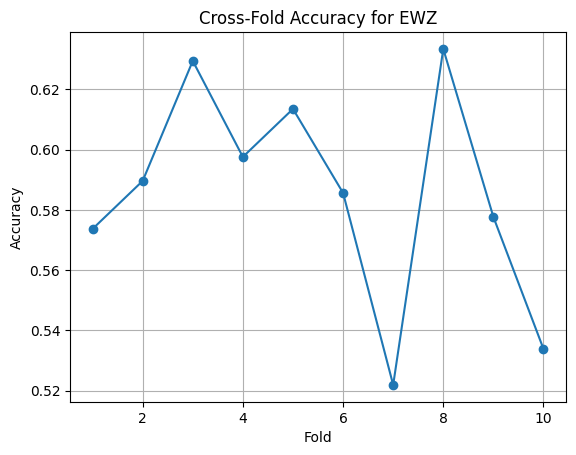

In [16]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), scores, marker="o", linestyle="-")
plt.title("Cross-Fold Accuracy for EWZ")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


![png](output_18_0.png)
